# Final Evaluation and Ultimate Judgement

**Status:** partial evaluation record. Saved Task 3 holdout results and analysis are included
in Sections 9–10. Other task sections remain a locked scaffold with their existing TODOs.
No training or new holdout inference runs here.

**Owner:** TODO(owner)


## 1. Final-evaluation contract

- One canonical split: `data/processed/splits.csv`
- Development is used for the final refit.
- Internal holdout is opened once, after the method is frozen.
- No tuning, model switching, metric switching, or threshold changes after unlock.
- Official prediction data is separate from the internal holdout.


## 2. Frozen inputs from task notebooks

| Output | Winning run ID | Frozen configuration | Frozen metric | CV evidence | Owner sign-off |
|---|---|---|---|---|---|
| TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) | TODO(owner) |

**Gate:** do not continue while any cell is TODO.


## 3. Select winning runs and lock decisions

- Comparison table generated from `results/runs.csv`: TODO(owner)
- Evidence-based winner for each required output: TODO(owner)
- Rejected alternatives and reason: TODO(owner)
- Decision-log timestamp before holdout access: TODO(owner)


## 4. Confirm metric and CV evidence

- Exact frozen metric definition for each output: TODO(owner)
- One-fold or five-fold evidence used: TODO(owner)
- Aggregation and uncertainty statement: TODO(owner)
- Known validation limitations: TODO(owner)

This section confirms prior choices; it does not invent a new metric.


## 5. Refit on all development

- Refit configuration matches the frozen winner: TODO(owner)
- All 32,773 development rows are eligible subject to the task label mask: TODO(owner)
- Seed/budget and scratch-training compliance: TODO(owner)
- Final refit run IDs in `results/runs.csv`: TODO(owner after execution)


## 6. Fit final preprocessing on all development

- Values that must be refitted: TODO(owner)
- Proof that only development was used: TODO(owner)
- Saved preprocessing configuration/hash: TODO(owner)
- Application rule for holdout and official prediction images: TODO(owner)


## 7. Lock final checkpoints and outputs

- Checkpoint/output paths: TODO(owner)
- File hashes: TODO(owner)
- Configuration hashes: TODO(owner)
- Lock timestamp before holdout access: TODO(owner)

**Gate:** checkpoint/configuration changes after this point invalidate the holdout.


## 8. Open internal holdout once

- Team approval and timestamp: TODO(owner)
- Explicit protected-loader call with `evaluation_unlocked=True`: TODO(owner after lock)
- Audit proof that access happened only here: TODO(owner)
- No output from this section exists before the lock gate passes.


## 9. Independent holdout evaluation

- Apply the frozen checkpoint and preprocessing without refit: TODO(owner)
- Compute only the frozen evaluation contract: TODO(owner)
- Append the final evaluation record: TODO(owner)
- Save traceable tables/figures: TODO(owner)

Report the result honestly. Do not return to candidate selection.


### 9.1 Task 3: scope of the completed holdout evaluation

The following cells reproduce **saved results**, not a new opening of protected data. Both targets
were scored on the 5,778 reserved teacher images. The saved audits report no overlap of holdout
IDs, exact-file hashes or saved product families with development. The labels came from the teacher
training metadata, joined by product ID; every holdout row was scored.

This is a Task 3 addition to the team scaffold. Other tasks' TODOs and gates remain pending.
Decisions [0020](../docs/decisions/0020-task3-gender-sam25-final-model.md) and
[0022](../docs/decisions/0022-task3-usage-e1-final-model.md) record Task 3 exceptions to the generic
all-development refit steps above: Gender SAM25 and Usage E1 use their five saved scratch-trained
fold models, each with its own normalisation. New-image probabilities are averaged equally.
These cells do not refit preprocessing, load model weights, run inference or change the registry.

**Timing matters.** Usage predictions were frozen on 6 September 2026 at 11:24:05 UTC, before
the scoring pass opened labels at 11:24:17. Gender predictions were frozen at 12:43:26, with labels
opened at 12:43:32. The final acceptance decisions followed evaluation review. Freezing predictions
before scoring does not make final model selection blind to the results. The holdout is now known
and must not be described as fresh selection data for later changes.

Sources: [Gender evaluation receipt](../reports/task3/gender_sam25_holdout_test_20260906/README.md)
and [Usage holdout receipt](../reports/task3/usage_holdout_20260906/README.md).
Official-test results are separate and are not imported into this holdout comparison.

### 9.2 Load tools

Import the tools used to read the saved tables and draw the figures.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

### 9.3 Gender: primary score and separate label diagnostic

In [2]:
EVAL_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src/fashion").is_dir()
)
gender_holdout = pd.read_csv(
    EVAL_ROOT / "reports/task3/main_report_20260906/holdout_summary.csv", keep_default_na=False
)

gender_table = gender_holdout.set_index("label_basis")[
    ["images", "correct", "incorrect", "accuracy", "macro_f1", "ece_15"]
].copy()
gender_table[["accuracy", "macro_f1", "ece_15"]] *= 100
display(
    gender_table.rename(
        index={
            "primary": "Original labels · primary",
            "fixed_name_rule_diagnostic": "Fixed name rule · diagnostic",
        },
        columns={
            "images": "Images",
            "correct": "Correct",
            "incorrect": "Wrong",
            "accuracy": "Accuracy (%)",
            "macro_f1": "Macro-F1 (%)",
            "ece_15": "Calibration error (%)",
        },
    ).round(2)
)

,Images,Correct,Wrong,Accuracy (%),Macro-F1 (%),Calibration error (%)
label_basis,,,,,,
Original labels · primary,5778,5190,588,89.82,77.14,2.35
Fixed name rule · diagnostic,5778,5224,554,90.41,80.45,2.83


**Result.** SAM25 gets **5,190/5,778** images right: **89.82% accuracy and 77.14% macro-F1**
against the original labels. Macro-F1 gives each of the five classes equal weight, exposing errors
that the larger adult classes hide in accuracy.

The fixed name-rule diagnostic gives 80.45% macro-F1. It changes 45 holdout labels, not the model's
predictions, so the 3.31-point difference is a scoring-basis effect, not an improvement learned on
holdout. The original-label result remains primary.

Original-label development OOF F1 was 75.33%; corrected-label OOF F1 was 79.73%. Compare each
only with its matching holdout label basis. Even then, the holdout uses a five-model average while
each development row has one held-out model. Population and prediction-rule differences prevent
attributing the score change to generalisation alone. The class analysis below shows the remaining
weakness despite the strong aggregate result.

### 9.4 Usage: accuracy and equal-class performance disagree

In [3]:
usage_holdout = pd.read_csv(
    EVAL_ROOT / "reports/task3/usage_holdout_20260906/holdout_summary.csv", keep_default_na=False
)

usage_names = {"E1": "E1 · baseline", "E8": "E8 · translation", "Expanded": "E8 +120 images"}
usage_table = usage_holdout.set_index("model")[
    [
        "scored_images",
        "correct",
        "incorrect",
        "accuracy",
        "macro_f1_nine_classes",
        "macro_f1_classes_present",
    ]
].copy()
usage_table[["accuracy", "macro_f1_nine_classes", "macro_f1_classes_present"]] *= 100
display(
    usage_table.rename(
        index=usage_names,
        columns={
            "scored_images": "Images",
            "correct": "Correct",
            "incorrect": "Wrong",
            "accuracy": "Accuracy (%)",
            "macro_f1_nine_classes": "Nine-class F1 (%)",
            "macro_f1_classes_present": "Eight present classes · diagnostic F1 (%)",
        },
    ).round(2)
)

,Images,Correct,Wrong,Accuracy (%),Nine-class F1 (%),Eight present classes · diagnostic F1 (%)
model,,,,,,
E1 · baseline,5778,5192,586,89.86,36.39,40.93
E8 · translation,5778,5149,629,89.11,37.59,42.29
E8 +120 images,5778,5154,624,89.20,39.48,44.42


**Result.** E1 gets **5,192/5,778** right: **89.86% accuracy and 36.39% nine-class macro-F1**.
Original E8 gets 5,149 right; E8 with 120 added images gets 5,154. Thus E1 has 43 and 38 more
correct predictions respectively. The expanded model has the best macro-F1 here, 39.48%, so an
accuracy preference accepts a cost in equal-class performance. These are recorded comparisons;
they do not establish that E1 is best under every objective. No 687-image holdout result is available.

Against original E8, adding 120 images fixes 70 errors but creates 65: just five net correct images.
Its 1.89-point macro-F1 gain includes about 1.59 points from a single newly correct NA example.
That is a useful class-specific change, but the tiny support does not establish a stable overall
benefit from adding data. The class breakdown below makes this sensitivity visible.

Home has no holdout examples. The fixed nine-class F1 convention assigns it zero; the separately
labelled eight-present-class values are diagnostics, not substitutes for the main comparison.
An absent class cannot be assessed for recall on this set.

## 10. Error, robustness, and cost analysis

- Representative holdout failures with IDs: TODO(owner)
- Predeclared slices and robustness checks: TODO(owner)
- Runtime, memory, storage, and practical cost: TODO(owner)
- Difference between validation expectation and holdout behaviour: TODO(owner)


### 10.1 Gender: which classes fail, and where do the errors go?

,Images,Predictions,precision,recall,f1
class_name,,,,,
Boys,120,136,0.6838,0.7750,0.7266
Girls,95,106,0.6887,0.7684,0.7264
Men,3130,3231,0.9167,0.9463,0.9313
Unisex,311,206,0.7087,0.4695,0.5648
Women,2122,2099,0.9128,0.9029,0.9078


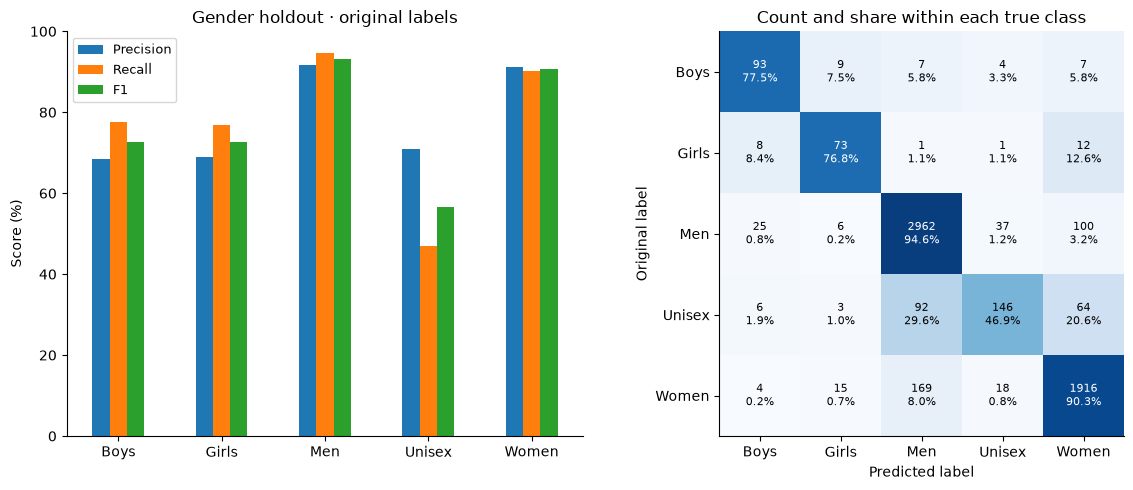

In [4]:
gender_classes = pd.read_csv(
    EVAL_ROOT / "reports/task3/main_report_20260906/holdout_per_class.csv", keep_default_na=False
)
gender_class_primary = gender_classes.loc[gender_classes.label_basis.eq("primary")].set_index(
    "class_name"
)
gender_cm = pd.read_csv(
    EVAL_ROOT / "reports/task3/main_report_20260906/holdout_confusion_matrix.csv",
    keep_default_na=False,
).set_index("actual")
HOLDOUT_FIGURES = EVAL_ROOT / "results/figures/task3/final_evaluation"
HOLDOUT_FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

display(
    gender_class_primary[["support", "predicted_count", "precision", "recall", "f1"]]
    .rename(columns={"support": "Images", "predicted_count": "Predictions"})
    .round(4)
)
gender_rates = gender_cm.div(gender_cm.sum(axis=1), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender_class_primary[["precision", "recall", "f1"]].mul(100).plot.bar(ax=axes[0], rot=0)
axes[0].set(ylabel="Score (%)", ylim=(0, 100), xlabel="", title="Gender holdout · original labels")
axes[0].legend(["Precision", "Recall", "F1"], fontsize=9)
axes[1].imshow(gender_rates, cmap="Blues", vmin=0, vmax=1)
axes[1].set(
    xticks=range(5),
    xticklabels=gender_cm.columns,
    yticks=range(5),
    yticklabels=gender_cm.index,
    xlabel="Predicted label",
    ylabel="Original label",
    title="Count and share within each true class",
)
for i, j in np.ndindex(gender_cm.shape):
    axes[1].text(
        j,
        i,
        f"{gender_cm.iloc[i, j]}\n{gender_rates.iloc[i, j]:.1%}",
        ha="center",
        va="center",
        fontsize=8,
        color="white" if gender_rates.iloc[i, j] > 0.55 else "black",
    )
fig.tight_layout()
fig.savefig(HOLDOUT_FIGURES / "gender_holdout_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**Unisex is the main weakness.** The model finds 146 of 311 Unisex products (46.95% recall).
Of the missed cases, 92 become Men, 64 Women, six Boys and three Girls. It makes only 206 Unisex
predictions for 311 true examples. Its Unisex precision is higher, 70.87%, showing a tendency to
miss this class rather than assign it broadly. The confusion pattern is consistent with difficulty
separating ambiguous audience cues; it does not identify which image feature caused an error.

Men and Women reach 93.13% and 90.78% F1. Together they supply 5,252/5,778 images, so their
strong performance dominates accuracy. Boys and Girls each reach about 72.6% F1, with precision
below recall. There are only 120 Boys and 95 Girls examples: a few mistakes or false positives can
move their scores more than the adult-class scores. No confidence interval is inferred from these
point estimates.

The mean calibration error of 2.35% is encouraging at the aggregate level, but does not certify
confidence for every class or product. These results support audience-tag suggestions with review
for ambiguous items. They do not support treating a product photo as a reliable statement about
a person's gender or an item's exclusive audience.

### 10.2 Usage: the majority class masks missing rare-class decisions

,support,correct,predicted_count,precision,recall,f1
class_name,,,,,,
Casual,4441,4253,4648,0.9150,0.9577,0.9359
Ethnic,384,314,365,0.8603,0.8177,0.8385
Formal,342,252,287,0.8780,0.7368,0.8013
Home,0,0,0,0.0000,0.0000,0.0000
NA,10,0,0,0.0000,0.0000,0.0000
Party,1,0,0,0.0000,0.0000,0.0000
Smart Casual,8,0,0,0.0000,0.0000,0.0000
Sports,589,373,478,0.7803,0.6333,0.6992
Travel,3,0,0,0.0000,0.0000,0.0000


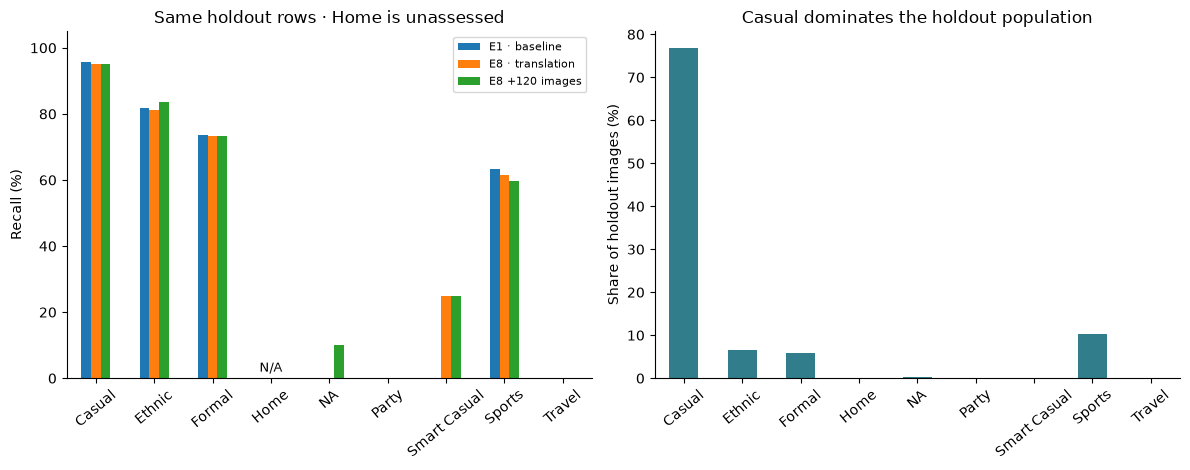

In [5]:
usage_classes = pd.read_csv(
    EVAL_ROOT / "reports/task3/usage_holdout_20260906/holdout_per_class.csv", keep_default_na=False
)

e1_classes = (
    usage_classes.loc[usage_classes.model.eq("E1")]
    .sort_values("class_index")
    .set_index("class_name")
)
display(e1_classes[["support", "correct", "predicted_count", "precision", "recall", "f1"]].round(4))
usage_recalls = (
    usage_classes.pivot(index="class_name", columns="model", values="recall")
    .reindex(e1_classes.index)
    .reindex(columns=["E1", "E8", "Expanded"])
)
usage_recalls.loc["Home"] = np.nan
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
usage_recalls.rename(columns=usage_names).mul(100).plot.bar(ax=axes[0], rot=40)
axes[0].set(
    ylabel="Recall (%)", ylim=(0, 105), xlabel="", title="Same holdout rows · Home is unassessed"
)
axes[0].annotate("N/A", (3, 2), ha="center", fontsize=9)
axes[0].legend(fontsize=8)
e1_classes.support.div(5778).mul(100).plot.bar(ax=axes[1], rot=40, color="#327d8b")
axes[1].set(
    ylabel="Share of holdout images (%)", xlabel="", title="Casual dominates the holdout population"
)
fig.tight_layout()
fig.savefig(HOLDOUT_FIGURES / "usage_holdout_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**E1's accuracy describes common classes much better than rare ones.** Casual accounts for
4,441/5,778 images (76.86%). E1 detects 4,253 of them, with 95.77% recall. Ethnic and Formal
also perform reasonably, but Sports recall falls to 63.33%: 216 Sports items become Casual.
That is the largest off-diagonal error route in E1's Usage confusion matrix.

E1 makes no predictions for NA, Party, Smart Casual or Travel, missing all 10, one, eight and three
examples respectively. This is a clear observed failure, even though those 22 images barely affect
overall accuracy. No Home images are present, so its zero in the scoring convention is not an
observed recall failure. The eight-class diagnostic still leaves E1 at only 40.93% F1.

E8 and expanded E8 each recover two of eight Smart Casual images, but their precision is only
11.76% and 14.29%. Expanded E8 detects one of ten NA examples. All three models miss Party
and Travel. Relative to E8, expansion adds seven correct Casual, nine Ethnic and one NA prediction,
but loses 12 Sports detections. The aggregate improvement therefore hides a real trade-off between
classes. These few rare examples cannot establish reliable tagging of those occasions.

**Limits and practical use.** The holdout is separate from development at the saved family level,
but the final acceptance decisions followed review of evaluation results. It is a completed audit,
not an untouched benchmark for future model selection. Development corruption results remain in
[Notebook 4](04_task3_gender_usage.ipynb); they are not holdout robustness measurements.
Five-model averaging requires five forward passes, and no application-latency benchmark is claimed
here. The evidence supports assisted catalogue tagging with known rare-class limits, not reliable
automatic assignment of every Usage class.

## 11. Ultimate judgement by required output

For each assignment output, state:

- what worked and the evidence;
- what failed and the evidence;
- whether it is fit for the stated user decision;
- the largest remaining risk;
- the next experiment that would most reduce uncertainty.

**Judgements: TODO(owner after independent evaluation).**


## 12. Official predictions and system handoff

- Generate the required prediction columns in the fixed order: TODO(owner)
- Verify ID order, row count, schema, and no missing values: TODO(owner)
- Build/freeze any application artifact after the evaluation decision: TODO(owner)
- Handoff paths and hashes to the app/report owners: TODO(owner)


## 13. Report-table and submission gate

- Comparison tables generated from registered runs: TODO(owner)
- Figure/table citations trace to artifacts: TODO(owner)
- Assignment filenames and submission structure checked: TODO(owner)
- Secrets, local paths, checkpoints, and accidental raw data checked: TODO(owner)
- Final team sign-off: TODO(owner)

**Final status: NOT READY — Task 3 holdout evidence is recorded; remaining task gates and team sign-off are pending.**
